# Comparación QAOA

Compara **CD-ADAPT-VQE** ($\ell=1$ y $\ell=2$) contra **QAOA/QOAO** sobre $n=6$, analizando dos tipos de instancias:

- **Grafos de referencia** ("benchmark instances"): los 4 grafos de referencia del paper de Xichen, guardados en `datos/grafos_comparacion.txt`.
- **Grafos regulares**: 4 grafos de grado 2 a 5 en `datos/grafos_regulares.txt`.

Los resultados completos (JSON) de ambos algoritmos para estas instancias están en `resultados/json/`.

## 0. Set-up

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

mpl.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.color"       : "#DDDDDD",
    "grid.linewidth"   : 0.6,
    "grid.alpha"       : 1.0,
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "legend.fontsize"  : 10,
    "legend.framealpha": 0.9,
    "legend.edgecolor" : "#BBBBBB",
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "lines.linewidth"  : 2.0,
    "patch.linewidth"  : 0.4,
    "savefig.dpi"      : 150,
    "savefig.bbox"     : "tight",
    "savefig.facecolor": "white",
})

# Colorblind-safe palette (Wong 2011)
C1 = "#0072B2"   # blue      – CD-ADAPT l = 1
C2 = "#D55E00"   # vermilion – CD-ADAPT l = 2
C3 = "#009E73"   # green     – QAOA

import sys
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from funciones.utilidades_QAOA import (
    cargar_resultados_json,
    error_relativo_desde_energias,
    cortar_por_max_params,
    cortar_qaoa_con_banda,
    cargar_imagen_con_fondo_transparente,
    agregar_imagen_dentro,
    convertir_adapt_a_diccionario_por_grafo,
    curva_adapt,
    convertir_qaoa_a_diccionario_por_grafo,
    extraer_errores_desde_all_runs,
    curva_qaoa_con_banda_desde_all_runs,
)

In [2]:
# CONFIGURACIÓN
# ============================================================

max_params_plot = None

# "iqr" usa percentiles 25-75; "std" usa media ± desviación estándar.
qaoa_band_type = "iqr"

# False: usa solo random_1, random_2, ...; True: incluye también warm-start.
incluir_warmstart_qaoa = False

# Mostrar el mejor reinicio de QAOA además de la mediana/banda.
mostrar_best_qaoa = False

mostrar_imagen_grafo = True
zoom_imagen_grafo = 0.075

# (0,0) = esquina inferior izquierda, (1,1) = esquina superior derecha (axes fraction)
posicion_imagen_grafo = (0.1, 0.43)

## 1. Carga de datos

**Grafos de referencia ("benchmark instances").** Son los 4 grafos de $n=6$ en `datos/grafos_comparacion.txt`. Acá se cargan los JSON completos de CD-ADAPT-VQE ($\ell=1,2$) y QAOA para esos mismos grafos, y se verifica qué `grafo_id` aparece en los tres archivos a la vez.

In [3]:
# RUTAS A LOS JSON COMPLETOS
# ============================================================

json_l1 = Path("../resultados/json/resultados_completos_comparacion_n6_l1.json")
json_l2 = Path("../resultados/json/resultados_completos_comparacion_n6_l2.json")
json_qaoa = Path("../resultados/json/resultados_qaoa_n6_p20_jx_r25_grafos_1_all.json")


# ============================================================
# RUTAS A IMÁGENES DE GRAFOS
# ============================================================

imagenes_grafos_dir = Path("../datos/imagenes/comparaciones")

imagenes_grafos = {
    1: imagenes_grafos_dir / "grafo_1.png",
    2: imagenes_grafos_dir / "grafo_2.png",
    3: imagenes_grafos_dir / "grafo_3.png",
    4: imagenes_grafos_dir / "grafo_4.png",
}


# ============================================================
# CARGAR DATOS
# ============================================================

data_l1 = cargar_resultados_json(json_l1)
data_l2 = cargar_resultados_json(json_l2)
data_qaoa = cargar_resultados_json(json_qaoa)

res_l1 = convertir_adapt_a_diccionario_por_grafo(data_l1)
res_l2 = convertir_adapt_a_diccionario_por_grafo(data_l2)
res_qaoa = convertir_qaoa_a_diccionario_por_grafo(data_qaoa)

grafos_comunes = sorted(
    set(res_l1.keys()) &
    set(res_l2.keys()) &
    set(res_qaoa.keys())
)

print("Grafos encontrados en los tres archivos:", grafos_comunes)

Grafos encontrados en los tres archivos: [1, 2, 3, 4]


**Grafos regulares.** Son los 4 grafos de `datos/grafos_regulares.txt` (grado 2, 3, 4 y 5), corridos de forma análoga a los de referencia. Acá se cargan sus JSON completos y se verifica igual qué `grafo_id` está presente en los tres archivos.

In [4]:
# RUTAS A LOS JSON COMPLETOS
# ============================================================

json_l1 = Path("../resultados/json/resultados_completos_regulares_n6_l1.json")
json_l2 = Path("../resultados/json/resultados_completos_regulares_n6_l2.json")
json_qaoa = Path("../resultados/json/resultados_qaoa_regulares_n6_p20_jx_r25_grafos_1_4.json")


# ============================================================
# RUTAS A IMÁGENES DE GRAFOS
# ============================================================

imagenes_grafos_dir = Path("../datos/imagenes/regulares")

imagenes_grafos = {
    1: imagenes_grafos_dir / "grado_2.png",
    2: imagenes_grafos_dir / "grado_3.png",
    3: imagenes_grafos_dir / "grado_4.png",
    4: imagenes_grafos_dir / "grado_5.png",
}


# ============================================================
# CARGAR DATOS
# ============================================================

data_l1 = cargar_resultados_json(json_l1)
data_l2 = cargar_resultados_json(json_l2)
data_qaoa = cargar_resultados_json(json_qaoa)

res_l1 = convertir_adapt_a_diccionario_por_grafo(data_l1)
res_l2 = convertir_adapt_a_diccionario_por_grafo(data_l2)
res_qaoa = convertir_qaoa_a_diccionario_por_grafo(data_qaoa)

grafos_comunes = sorted(
    set(res_l1.keys()) &
    set(res_l2.keys()) &
    set(res_qaoa.keys())
)

print("Grafos encontrados en los tres archivos:", grafos_comunes)

Grafos encontrados en los tres archivos: [1, 2, 3, 4]


## 2. Análisis grafos de referencia

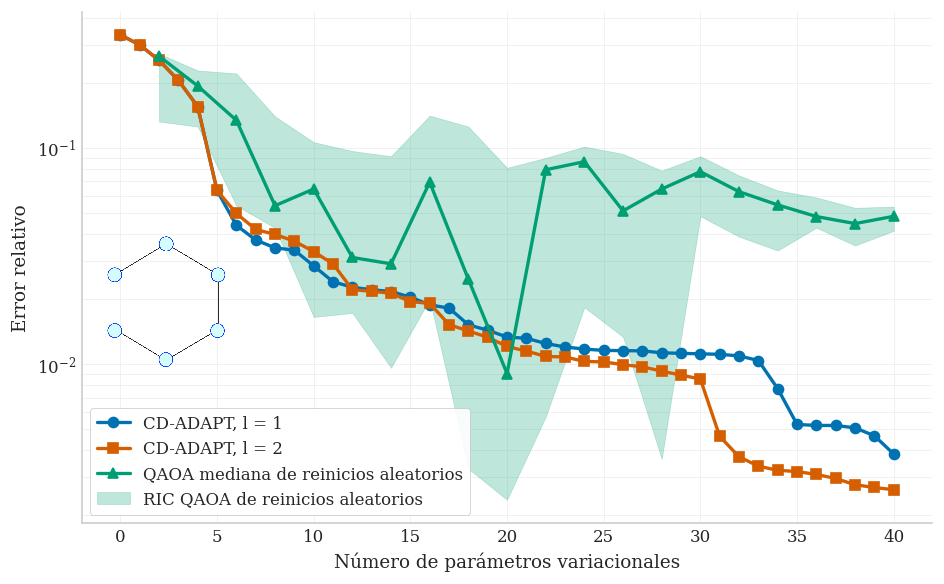

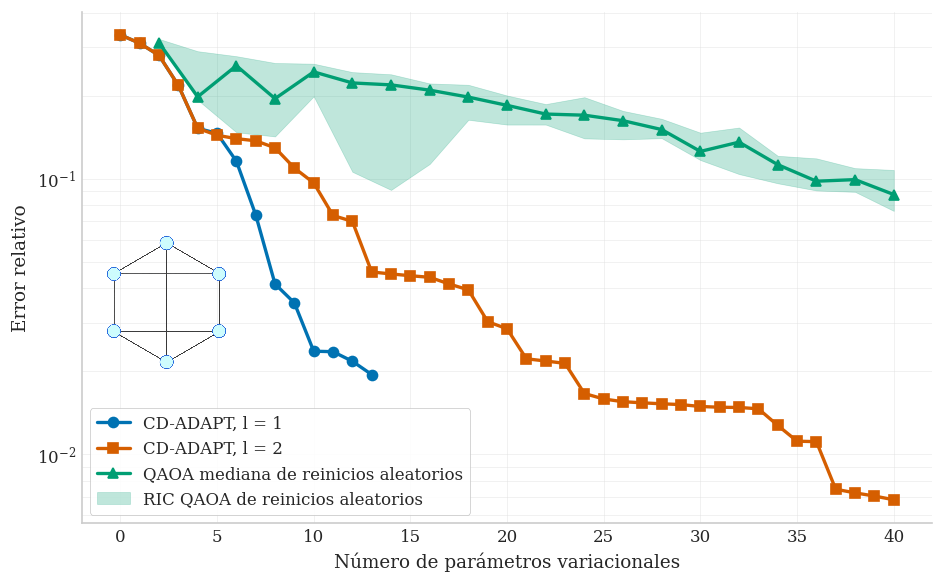

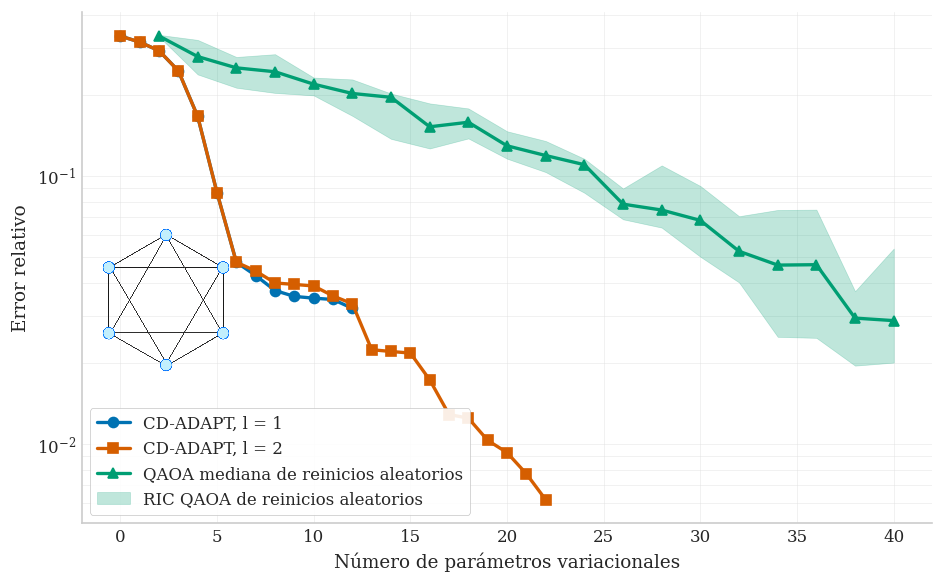

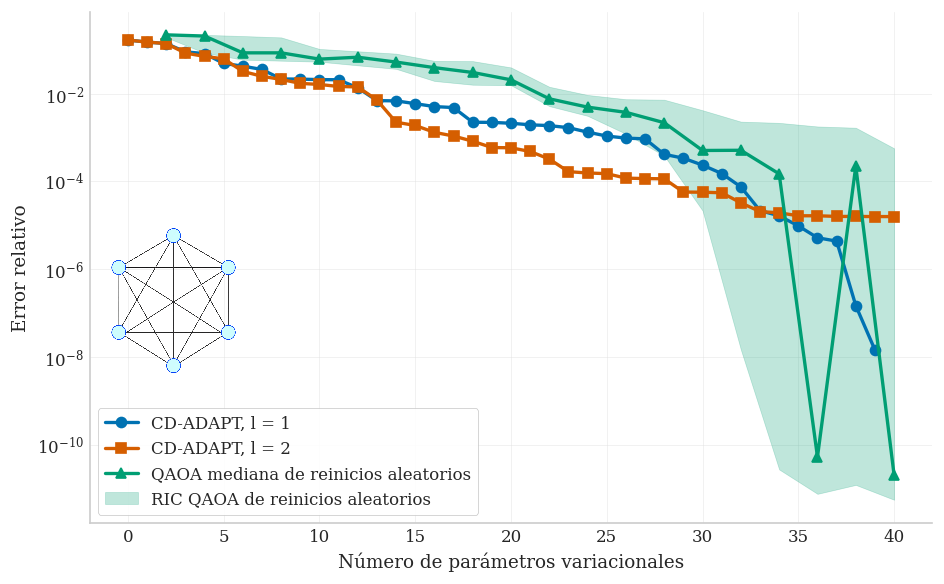

In [5]:
# ============================================================
# GENERAR UN GRÁFICO POR GRAFO — Benchmark instances
# ============================================================

for grafo_id in grafos_comunes:

    r1 = res_l1[grafo_id]
    r2 = res_l2[grafo_id]
    rq = res_qaoa[grafo_id]

    # Curvas ADAPT
    x_l1, err_l1 = curva_adapt(r1)
    x_l2, err_l2 = curva_adapt(r2)

    # Curva QAOA con banda desde all_runs
    (
        x_qaoa,
        err_qaoa_central,
        err_qaoa_low,
        err_qaoa_high,
        err_qaoa_best,
    ) = curva_qaoa_con_banda_desde_all_runs(
        rq,
        band_type=qaoa_band_type,
        incluir_warmstart=incluir_warmstart_qaoa,
    )

    # Cortar ADAPT
    x_l1, err_l1 = cortar_por_max_params(x_l1, err_l1, max_params_plot)
    x_l2, err_l2 = cortar_por_max_params(x_l2, err_l2, max_params_plot)

    # Cortar QAOA
    (
        x_qaoa,
        err_qaoa_central,
        err_qaoa_low,
        err_qaoa_high,
        err_qaoa_best,
    ) = cortar_qaoa_con_banda(
        x_qaoa,
        err_qaoa_central,
        err_qaoa_low,
        err_qaoa_high,
        err_qaoa_best,
        max_params_plot,
    )

    # ========================================================
    # PLOT
    # ========================================================

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        x_l1,
        err_l1,
        marker="o",
        color=C1,
        label="CD-ADAPT, l = 1"
    )

    ax.plot(
        x_l2,
        err_l2,
        marker="s",
        color=C2,
        label="CD-ADAPT, l = 2"
    )

    ax.plot(
        x_qaoa,
        err_qaoa_central,
        marker="^",
        color=C3,
        label="QAOA mediana de reinicios aleatorios"
        if qaoa_band_type == "iqr"
        else "QAOA media de reinicios aleatorios"
    )

    ax.fill_between(
        x_qaoa,
        err_qaoa_low,
        err_qaoa_high,
        alpha=0.25,
        color=C3,
        label="RIC QAOA de reinicios aleatorios"
        if qaoa_band_type == "iqr"
        else "QAOA ± std de reinicios aleatorios"
    )

    if mostrar_best_qaoa:
        ax.plot(
            x_qaoa,
            err_qaoa_best,
            linestyle="--",
            marker="x",
            color=C3,
            alpha=0.8,
            label="Mejor reinicio QAOA"
        )

    ax.set_yscale("log")
    ax.set_xlabel("Número de parámetros variacionales")
    ax.set_ylabel("Error relativo")
    #x.set_title(f"Grafo de referencia {grafo_id}: error relativo vs. número de parámetros")
    ax.grid(True, which="both", alpha=0.4)

    # Imagen dentro de la gráfica, justo arriba de la leyenda
    if mostrar_imagen_grafo and grafo_id in imagenes_grafos:
        agregar_imagen_dentro(
            ax,
            imagenes_grafos[grafo_id],
            zoom=zoom_imagen_grafo,
            xy=posicion_imagen_grafo
        )

    # Leyenda abajo a la izquierda
    ax.legend(
        loc="lower left",
        frameon=True,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()
    plt.close()

## 3. Análisis grafos regulares

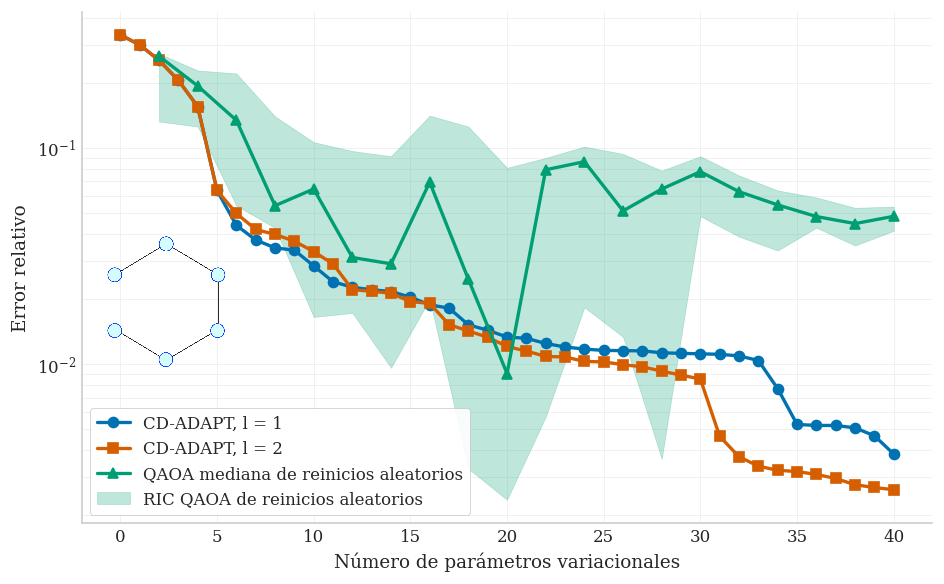

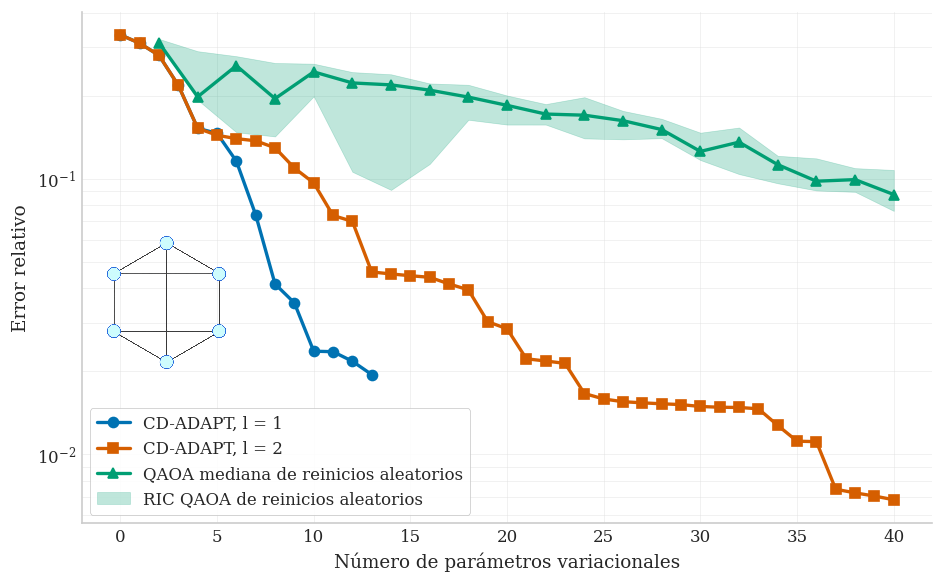

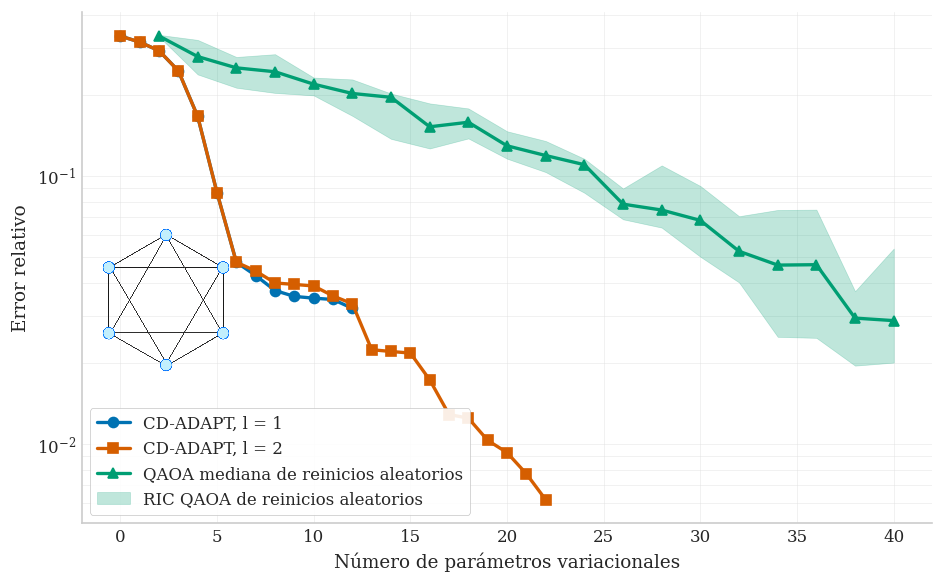

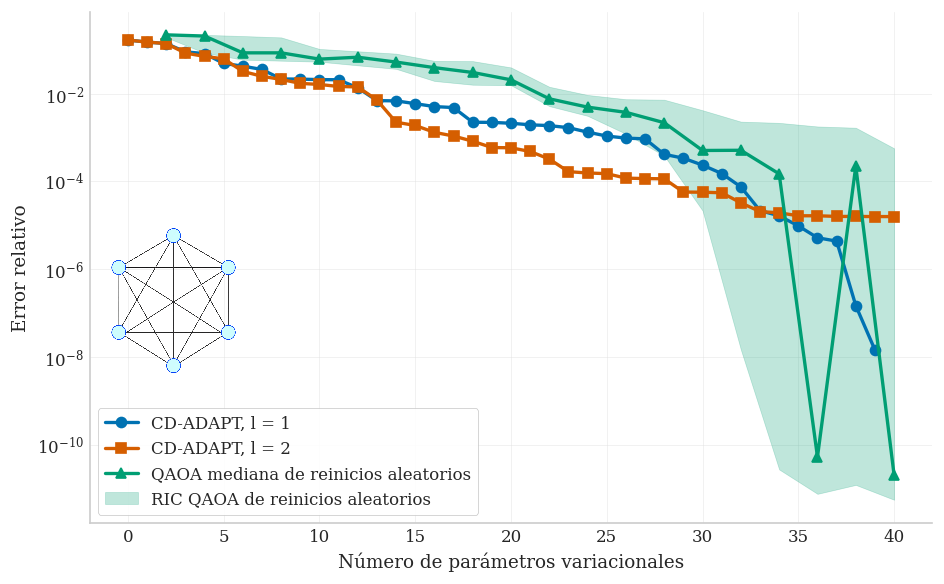

In [6]:
# Mapeo de grafo_id -> grado del grafo regular
GRADO_REGULAR = {1: 2, 2: 3, 3: 4, 4: 5}

# ============================================================
# GENERAR UN GRÁFICO POR GRAFO — Regular graph instances
# ============================================================

for grafo_id in grafos_comunes:

    r1 = res_l1[grafo_id]
    r2 = res_l2[grafo_id]
    rq = res_qaoa[grafo_id]

    # Curvas ADAPT
    x_l1, err_l1 = curva_adapt(r1)
    x_l2, err_l2 = curva_adapt(r2)

    # Curva QAOA con banda desde all_runs
    (
        x_qaoa,
        err_qaoa_central,
        err_qaoa_low,
        err_qaoa_high,
        err_qaoa_best,
    ) = curva_qaoa_con_banda_desde_all_runs(
        rq,
        band_type=qaoa_band_type,
        incluir_warmstart=incluir_warmstart_qaoa,
    )

    # Cortar ADAPT
    x_l1, err_l1 = cortar_por_max_params(x_l1, err_l1, max_params_plot)
    x_l2, err_l2 = cortar_por_max_params(x_l2, err_l2, max_params_plot)

    # Cortar QAOA
    (
        x_qaoa,
        err_qaoa_central,
        err_qaoa_low,
        err_qaoa_high,
        err_qaoa_best,
    ) = cortar_qaoa_con_banda(
        x_qaoa,
        err_qaoa_central,
        err_qaoa_low,
        err_qaoa_high,
        err_qaoa_best,
        max_params_plot,
    )

    # ========================================================
    # PLOT
    # ========================================================

    degree = GRADO_REGULAR.get(grafo_id, grafo_id)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        x_l1,
        err_l1,
        marker="o",
        color=C1,
        label="CD-ADAPT, l = 1"
    )

    ax.plot(
        x_l2,
        err_l2,
        marker="s",
        color=C2,
        label="CD-ADAPT, l = 2"
    )

    ax.plot(
        x_qaoa,
        err_qaoa_central,
        marker="^",
        color=C3,
        label="QAOA mediana de reinicios aleatorios"
        if qaoa_band_type == "iqr"
        else "QAOA media de reinicios aleatorios"
    )

    ax.fill_between(
        x_qaoa,
        err_qaoa_low,
        err_qaoa_high,
        alpha=0.25,
        color=C3,
        label="RIC QAOA de reinicios aleatorios"
        if qaoa_band_type == "iqr"
        else "QAOA ± std de reinicios aleatorios"
    )

    if mostrar_best_qaoa:
        ax.plot(
            x_qaoa,
            err_qaoa_best,
            linestyle="--",
            marker="x",
            color=C3,
            alpha=0.8,
            label="Mejor reinicio QAOA"
        )

    ax.set_yscale("log")
    ax.set_xlabel("Número de parámetros variacionales")
    ax.set_ylabel("Error relativo")
    #x.set_title(f"Grafo regular (grado {degree}): error relativo vs. número de parámetros")
    ax.grid(True, which="both", alpha=0.4)

    # Imagen dentro de la gráfica, justo arriba de la leyenda
    if mostrar_imagen_grafo and grafo_id in imagenes_grafos:
        agregar_imagen_dentro(
            ax,
            imagenes_grafos[grafo_id],
            zoom=zoom_imagen_grafo,
            xy=posicion_imagen_grafo
        )

    # Leyenda abajo a la izquierda
    ax.legend(
        loc="lower left",
        frameon=True,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()
    plt.close()